In [11]:
import pandas as pd
import numpy as np
import requests, zipfile, io
from scipy.fft import fft

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
# 1. DOWNLOAD DATASET
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))


In [13]:
# 2. LOAD FEATURES + FIX DUPLICATES
features = pd.read_csv(
    z.open("UCI HAR Dataset/features.txt"),
    sep=r"\s+",
    header=None,
    names=["index", "feature"]
)["feature"].tolist()

counts = Counter(features)
new_features = []
used = {}

for feat in features:
    if counts[feat] == 1:
        new_features.append(feat)
    else:
        used.setdefault(feat, 0)
        new_features.append(f"{feat}_{used[feat]}")
        used[feat] += 1

In [14]:
# 3. LOAD TRAIN DATA
X_train_raw = pd.read_csv(
    z.open("UCI HAR Dataset/train/X_train.txt"),
    sep=r"\s+",
    header=None,
    names=new_features
)

y_train_raw = pd.read_csv(
    z.open("UCI HAR Dataset/train/y_train.txt"),
    sep=r"\s+",
    header=None,
    names=["Activity"]
)

subject_train = pd.read_csv(
    z.open("UCI HAR Dataset/train/subject_train.txt"),
    sep=r"\s+",
    header=None,
    names=["Subject"]
)

df = pd.concat([subject_train, y_train_raw, X_train_raw], axis=1)
print("FINAL SHAPE:", df.shape)

FINAL SHAPE: (7352, 563)


In [15]:
# 4. FEATURE EXTRACTION FUNCTION
def extract_features(signal):
    signal = np.array(signal)
    features = {}

    # Statistical
    features['mean'] = np.mean(signal)
    features['median'] = np.median(signal)
    features['std'] = np.std(signal)
    features['var'] = np.var(signal)
    features['min'] = np.min(signal)
    features['max'] = np.max(signal)
    features['skew'] = pd.Series(signal).skew()
    features['kurtosis'] = pd.Series(signal).kurt()

    # Temporal
    features['zcr'] = ((signal[:-1] * signal[1:]) < 0).sum()
    features['energy'] = np.sum(signal**2)
    features['ptp'] = np.ptp(signal)
    features['sma'] = np.sum(np.abs(signal)) / len(signal)

    # Frequency
    fft_vals = np.abs(fft(signal))
    fft_norm = fft_vals / np.sum(fft_vals)

    features['spectral_centroid'] = np.sum(np.arange(len(fft_vals)) * fft_vals) / np.sum(fft_vals)
    features['spectral_entropy'] = -np.sum(fft_norm * np.log(fft_norm + 1e-10))

    return features

In [16]:
# 5. APPLY FEATURE EXTRACTION
print("Extracting features...")

feature_rows = []
for i in range(len(X_train_raw)):
    row_signal = X_train_raw.iloc[i]
    feats = extract_features(row_signal)
    feats["label"] = int(y_train_raw.iloc[i].values[0]) - 1  # convert 1–6 → 0–5
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)
print("Feature extraction completed!")

Extracting features...
Feature extraction completed!


In [17]:
# 6. PREPARE ML DATA
X = features_df.drop("label", axis=1)
y = features_df["label"]

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ml)
X_test_scaled = scaler.transform(X_test_ml)

In [18]:
# 7. TRAIN MODELS
print("Training models...")

# Logistic Regression
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train_scaled, y_train_ml)
pred_lr = log_reg.predict(X_test_scaled)

# SVM
svm_clf = SVC(kernel='rbf')
svm_clf.fit(X_train_scaled, y_train_ml)
pred_svm = svm_clf.predict(X_test_scaled)

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=180)
rf_clf.fit(X_train_ml, y_train_ml)
pred_rf = rf_clf.predict(X_test_ml)

# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=7,
    subsample=0.8,
    objective='multi:softmax',
    num_class=6  # because labels = 0–5
)
xgb.fit(X_train_ml, y_train_ml)
pred_xgb = xgb.predict(X_test_ml)


Training models...


In [19]:
# 8. METRICS FUNCTION
def print_metrics(name, y_true, y_pred):
    print("\n---------------------------")
    print(f"{name} RESULTS")
    print("---------------------------")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

print_metrics("Logistic Regression", y_test_ml, pred_lr)
print_metrics("SVM", y_test_ml, pred_svm)
print_metrics("Random Forest", y_test_ml, pred_rf)
print_metrics("XGBoost", y_test_ml, pred_xgb)



---------------------------
Logistic Regression RESULTS
---------------------------
Accuracy : 0.6159075458871516
Precision: 0.6123261774807292
Recall   : 0.6159075458871516
F1 Score : 0.6060058426881796
Confusion Matrix:
 [[194  34  19   0   0   0]
 [ 45 145  10   0   0   0]
 [ 45  40 120   0   1   0]
 [  0   0   0  73  87 102]
 [  0   0   0  53 179  44]
 [  0   0   0  40  45 195]]

---------------------------
SVM RESULTS
---------------------------
Accuracy : 0.6084296397008837
Precision: 0.6075443440279964
Recall   : 0.6084296397008837
F1 Score : 0.5966742299211688
Confusion Matrix:
 [[200  30  17   0   0   0]
 [ 38 144  18   0   0   0]
 [ 44  31 131   0   0   0]
 [  0   0   0  64 102  96]
 [  0   0   0  35 188  53]
 [  0   0   0  34  78 168]]

---------------------------
Random Forest RESULTS
---------------------------
Accuracy : 0.6383412644459552
Precision: 0.6365738175849894
Recall   : 0.6383412644459552
F1 Score : 0.6352799665261518
Confusion Matrix:
 [[202  26  19   0   0   

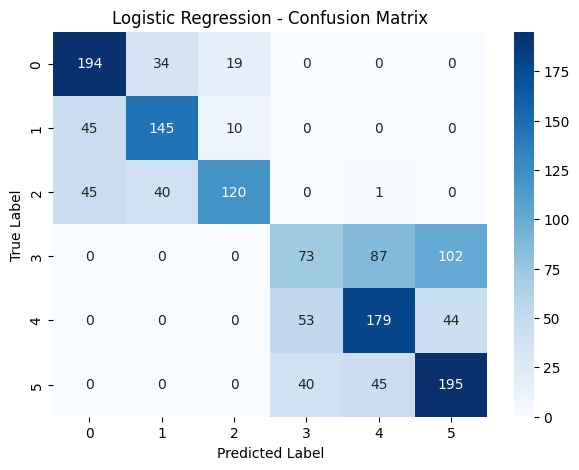

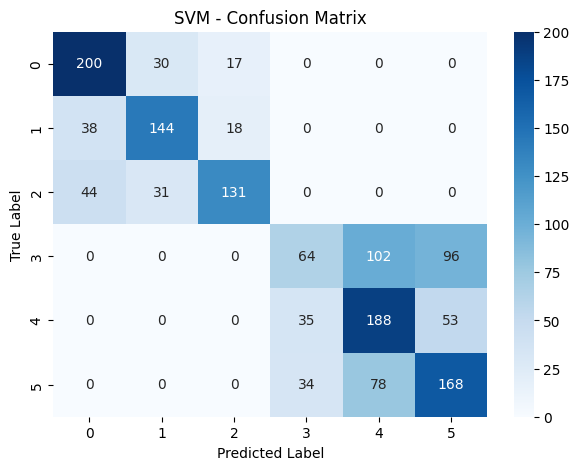

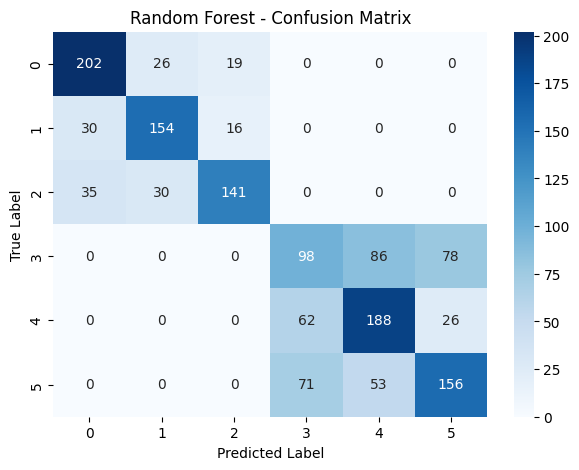

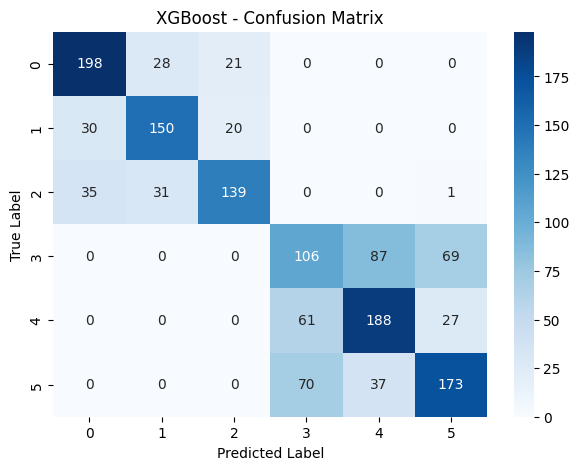

In [20]:

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# Plot for each model
plot_conf_matrix(y_test_ml, pred_lr, "Logistic Regression - Confusion Matrix")
plot_conf_matrix(y_test_ml, pred_svm, "SVM - Confusion Matrix")
plot_conf_matrix(y_test_ml, pred_rf, "Random Forest - Confusion Matrix")
plot_conf_matrix(y_test_ml, pred_xgb, "XGBoost - Confusion Matrix")